# Heavy Rainfall

Analysis of wet-day frequency and extreme (heavy) rainfall days at the selected GHCN station.

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

```{glue:figure} number_wet_days
:scale: 60%
:align: center
```

```{glue:figure} number_over_95
:scale: 60%
:align: center
```

**Figure. Annual wet days (top) and heavy-rainfall days (bottom).** Wet days are days with `PRCP ≥ 1 mm`. Heavy-rainfall days exceed the 95th percentile of the station record. A solid black line indicates a statistically significant trend (p < 0.05); a dashed line indicates a non-significant trend.

## Setup

Import libraries and helper functions from `functions/rainfall.py` and [indicators_setup](https://github.com/lauracagigal/indicators_setup).

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os.path as op
import sys
from pathlib import Path

from myst_nb import glue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append("../../../../../../indicators_setup")
from ind_setup.plotting import plot_bar_probs
from ind_setup.colors import get_df_col
from ind_setup.core import fontsize

sys.path.append("../../../../functions")
from rainfall import (
    load_site_config,
    site_config_filename,
    list_available_sites,
    build_site_figures_dir,
    build_output_filename,
    persist_heavy_rainfall_outputs,
)

### Define location and variables of interest

Set `site_key` to one of the sites already configured with [`../00_site_setup.ipynb`](../00_site_setup.ipynb) (see the list printed below). Site metadata and output paths are loaded from `data/sites/<site_key>.json`.

In [3]:
sites_dir = Path("../../../../data/sites")
available_sites = list_available_sites(sites_dir)
print(f"{len(available_sites)} site(s) already configured in {sites_dir}:")
display(available_sites)

6 site(s) already configured in ../../../../data/sites:


,site_key,site_name,country,ghcn_station_id,ghcn_station_name,vars_interest
0,cook_islands_new_zealand_cwm00091843,cook_islands_new_zealand_CWM00091843,Cook Islands [New Zealand],CWM00091843,RAROTONGA INTL GSN 91843,"[TMIN, TMAX, PRCP]"
1,marshall_islands_rmw00040604,marshall_islands_RMW00040604,Marshall Islands,RMW00040604,MH KWAJALEIN GSN 91366,"[TMIN, TMAX, PRCP]"
2,marshall_islands_rmw00040710,marshall_islands_RMW00040710,Marshall Islands,RMW00040710,MH MAJURO WBAS AP GSN 91376,"[TMIN, TMAX, PRCP]"
3,niue_new_zealand_nem00091824,niue_new_zealand_NEM00091824,Niue [New Zealand],NEM00091824,HANAN AIRPORT GSN 91824,"[TMIN, TMAX, PRCP]"
4,palau,Palau,Palau,None,None,None
5,palau_psw00040309,palau_PSW00040309,Palau,PSW00040309,PW KOROR GSN 91408,"[TMIN, TMAX, PRCP]"


### Get Data

Load the cached daily `PRCP` pickle from `data/rainfall/GHCN_<station_id>.pkl`. All download and quality-control steps were completed in [`../00_site_setup.ipynb`](../00_site_setup.ipynb).

In [4]:
site_key = "palau_psw00040309"  # pick a site_key from the table printed above

site_config_path = sites_dir / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get("site_name", "Site")
site_lon = float(site_cfg["site_lon"])
site_lat = float(site_cfg["site_lat"])
country = site_cfg["country"]
ghcn_station_id = site_cfg["ghcn_station_id"]
ghcn_station_name = site_cfg.get("ghcn_station_name", "")
vars_interest = list(site_cfg.get("vars_interest", ["PRCP"]))
ref_start = str(site_cfg.get("reference_period_start", "1961"))
ref_end = str(site_cfg.get("reference_period_end", "1990"))



In [5]:
data_base_dir = Path("../../../../data")
site_figures_dir = build_site_figures_dir(Path("../../../../outputs"), site_name, site_lon, site_lat)
data_dir = Path(data_base_dir, "rainfall")

data_dir.mkdir(parents=True, exist_ok=True)
path_data = str(data_dir)

### Observations from Station

Daily precipitation records for the GHCN station defined in the site configuration.

[GHCN-Daily documentation](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/doc/GHCND_documentation.pdf)

The data used for this analysis comes from the [GHCN-Daily](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/) database (NOAA NCEI).

GHCN-Daily provides historical daily climate records over global land areas. Records from numerous sources are merged and subjected to quality-assurance reviews. The variable used here is **`PRCP`** (daily precipitation total, mm).

**Data loading:** this notebook reads the pre-processed pickle created by [`../00_site_setup.ipynb`](../00_site_setup.ipynb). It does **not** re-download from NOAA.

**Outputs:** figures → `outputs/figures/<site_tag>/`; tables and JSON → `outputs/tables/<site_tag>/`.

In [6]:
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"
data = pd.read_pickle(pickle_path)
print(f"Loaded {len(data)} daily records from {pickle_path}")
data_daily = data.copy()


Loaded 26652 daily records from ../../../../data/rainfall/GHCN_PSW00040309.pkl


#### Wet and dry day classification

Each day is classified as wet (`PRCP ≥ 1 mm`) or dry. Month/year completeness filtering was already applied once in [`../00_site_setup.ipynb`](../00_site_setup.ipynb) before caching the pickle — this notebook does not re-filter years by observation count.

In [7]:
data = data.dropna()

glue("n_years", len(np.unique(data.index.year)), display=False)



In [8]:
data['wet_day'] = np.where(data['PRCP'] >= 1, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))



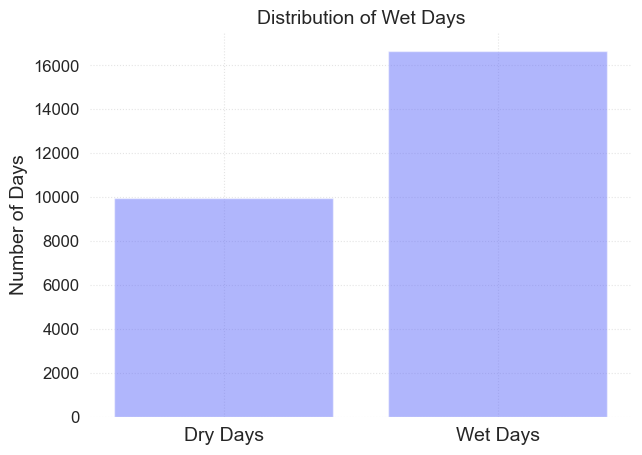

In [9]:
fig, ax = plot_bar_probs(x = [0, 1], y = data.groupby('wet_day').count()['PRCP'].values, labels = ['Dry Days', 'Wet Days'])
ax.set_title('Distribution of Wet Days', fontsize = fontsize)
ax.set_ylabel('Number of Days', fontsize = fontsize)
plt.savefig(
    site_figures_dir / build_output_filename('F7a_Wet_dry_distribution', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)


#### Annual wet-day counts (> 1 mm)

Number of wet days per year with a fitted linear trend. Saved as `F7a_Wet_days_1mm_<site_tag>.png`.

In [10]:
threshold = 1 #np.percentile(data['PRCP'].dropna(), 90)
data['wet_day_t'] = np.where(data['PRCP'] > threshold, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))
data_th_1mm = data.copy()



In [11]:
data_th = data.groupby([data.index.year, data.wet_day_t]).count()['PRCP']
data_th = data_th/data.groupby(data.index.year).count()['PRCP'] * 365



Text(0, 0.5, 'Number of days')

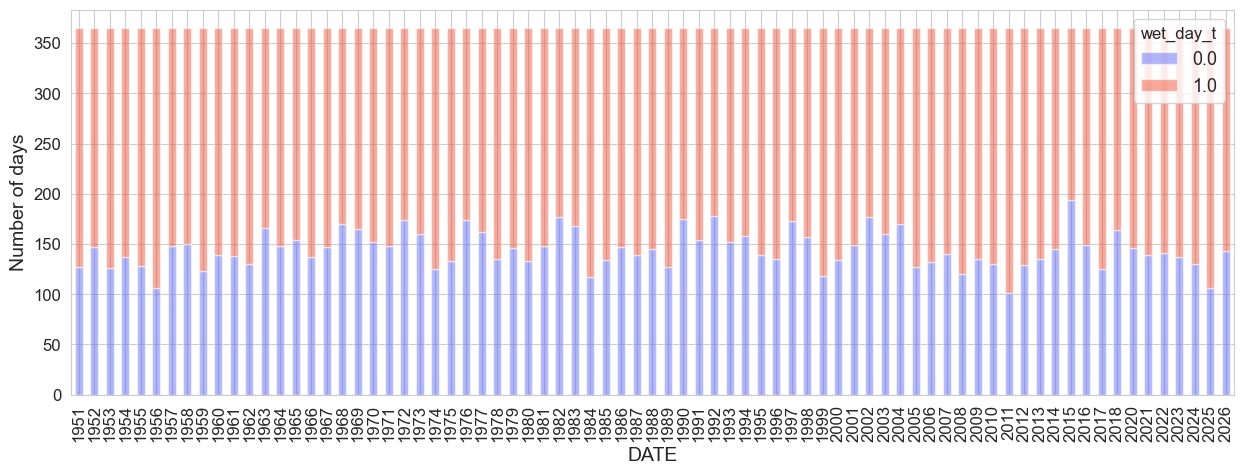

In [12]:
fig, ax = plt.subplots(figsize = [15, 5])
data_th.unstack().plot(kind = 'bar', stacked = True, ax = ax, color = get_df_col()[:2], edgecolor = 'white', alpha = .5)
ax.set_ylabel('Number of days', fontsize = fontsize)



Stacked bar chart of wet and dry days per year (exploratory).

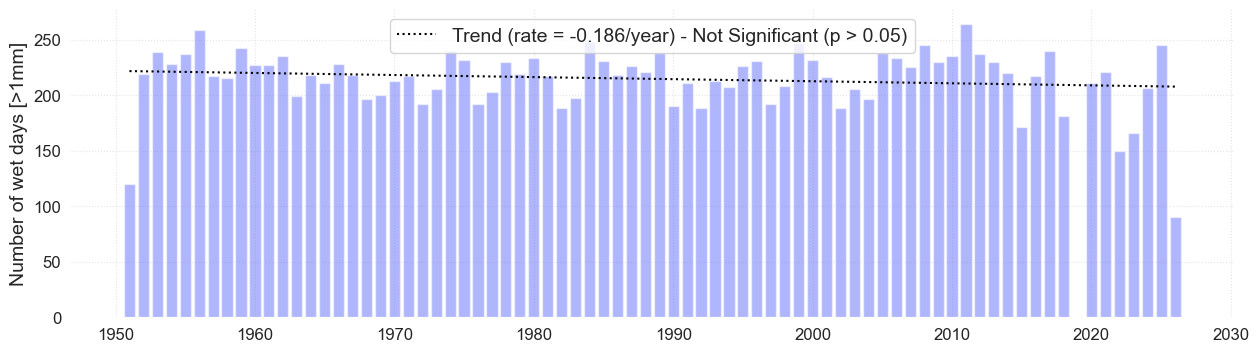

In [13]:
#Wet days
data2 = data.loc[data['wet_day_t'] == 1]
data2 = data2.groupby(data2.index.year).count()
fig, ax, trend_wet = plot_bar_probs(x = data2.index, y = data2.PRCP.values, trendline = True,
               y_label = 'Number of wet days [>1mm]', figsize = [15, 4], return_trend = True)
wet_days_per_year = pd.DataFrame({'year': data2.index, 'wet_days': data2['PRCP'].values})
plt.savefig(
    site_figures_dir / build_output_filename('F7a_Wet_days_1mm', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue("number_wet_days", fig, display=False)

glue("trend_wet", float(trend_wet), display=False)

## Analysis — heavy rainfall days

### Days above the 95th percentile

**Heavy rainfall day:** daily `PRCP` exceeds the 95th percentile of the full station record. The threshold is computed from all available years and rounded to two decimal places.

This metric tracks changes in the extreme rainfall regime independent of the 1 mm wet-day threshold.

In [14]:
prcentile = 95
data = data.drop('wet_day', axis = 1)
threshold = np.round(np.percentile(data['PRCP'].dropna(), prcentile), 2)
print(f'Threshold of {threshold}mm')
data['wet_day_t'] = np.where(data['PRCP'] > threshold, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))
data_th_95 = data.copy()



Threshold of 45.2mm


In [15]:
data_2 = data.loc[data['wet_day_t'] == 1][['PRCP']]
data_over_th = data_2.groupby(data_2.index.year).count()
data_over_th.index = pd.to_datetime(data_over_th.index, format = '%Y')




In [16]:
data_over_th['PRCP_below'] = 365 - data_over_th['PRCP'].values



In [17]:
dict_plot = [{'data' : data_over_th, 'var' : 'PRCP', 'ax' : 1, 'label':f'Number of days over threshold: {threshold}mm'},]



In [18]:
data_over_th



,PRCP,PRCP_below
DATE,,
1951-01-01,4,361
1952-01-01,25,340
1953-01-01,19,346
1954-01-01,20,345
1955-01-01,9,356
...,...,...
2022-01-01,23,342
2023-01-01,18,347
2024-01-01,14,351


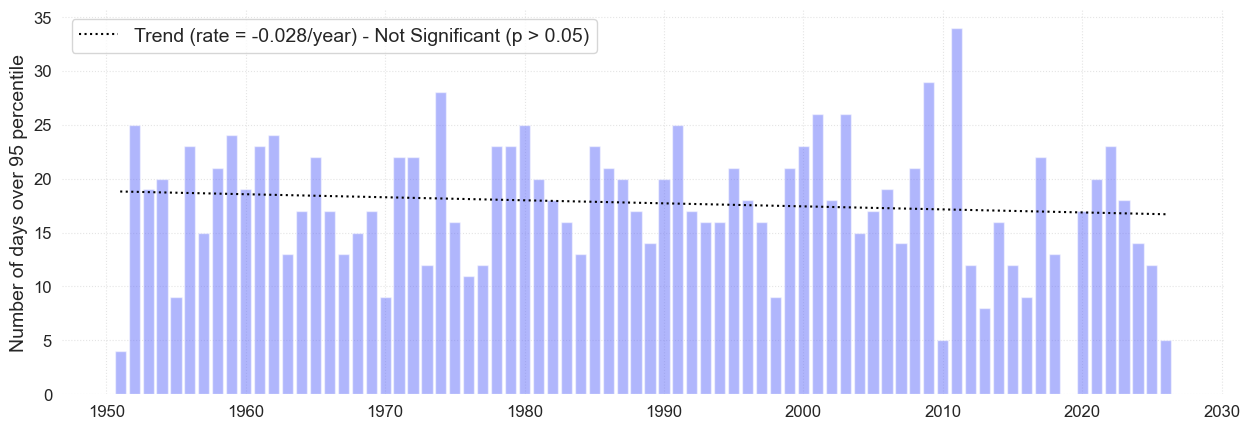

In [19]:
fig, ax, trend_95 = plot_bar_probs(x = data_over_th.index.year, y = data_over_th['PRCP'].values, trendline = True,
               figsize = (15, 5), return_trend = True, y_label = f'Number of days over {prcentile} percentile')
heavy_days_per_year = pd.DataFrame({'year': data_over_th.index.year, 'heavy_days': data_over_th['PRCP'].values})

plt.savefig(
    site_figures_dir / build_output_filename('F7b_Wet_days_95p', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue('number_over_95', fig, display=False)

### Summary table and persisted outputs

Calls `persist_heavy_rainfall_outputs()` to save:

- `R_wet_days_per_year_<site_tag>.csv`
- `R_heavy_days_per_year_<site_tag>.csv`
- `R_heavy_summary_table_<site_tag>.csv`
- `R_heavy_summary_metrics_<site_tag>.json`

In [20]:
from ind_setup.tables import table_rain_23

summary_table = table_rain_23(data_th_1mm, data_th_95, trend_wet, trend_95)
persist_heavy_rainfall_outputs(
    Path('../../../../outputs'),
    site_name, site_lon, site_lat,
    ghcn_station_id, ghcn_station_name, country,
    wet_days_per_year, heavy_days_per_year, summary_table,
    trend_wet, trend_95, threshold,
)

Metric,Value
Annual average of wet days,214.667
Change in number of wet days from 1952,-13.764
Rate of change in number of wet days,-0.186
Average Number of Wet Days: 1952 - 1962,240.091
Average Number of Wet Days: 2012 - 2022,215.000
Wet days in the wettest year: 2011,269.000
,
Annual average number of days with heavy rainfall (>95th percentile),17.760
Maximum number of days with heavy rainfall (>95th percentile): 2011,34.000
Minimum number of days with heavy rainfall (>95th percentile): 1951,4.000


PosixPath('../../../../outputs/tables/palau_psw00040309_lat7p337_lon134p477')

## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Station coverage, missing observations, relocations and instrument changes can affect apparent variability and trends.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.